# Beyond BLAST Notebook

In [1]:
using Base.Threads
println("Threads available: ", Threads.nthreads())

Threads available: 8


In [2]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 

using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration, Trapz
using CSV, DataFrames, JSON, OrderedCollections
using MCIntegration
;

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2092.3 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-b4ad-7cc2-e694-dec09f83c757 is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    633.0 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

In [31]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
include("blast_code/src/config.jl")
include("blast_code/src/paths.jl")
include("blast_code/src/plot_config.jl")
using .galaxy_galaxy
using .shear_shear
using .Blast
using .blast_tutorials

Wtilde_quadgk: ℓ=2.0, k1=0.01574015850603505, ki=7.565305025715951, val=-8.214480433898306e-12, err=3.2314932602098946e-18


Wtilde_quadgk: ℓ=2.0, k1=0.01574015850603505, ki=10.547783431730325, val=3.908471224933743e-12, err=3.8627883630882366e-18


In [32]:
import PhysicalConstants.CODATA2018: c_0 # speed of light in m/s

In [51]:
paths = setup_output_directories()
grid_data = setup_cosmology_grid() 
grids = Blast.generate_k_grids(grid_data.kmin, grid_data.kmax, grid_data.Nk, grid_data.Nkp, grid_data.Nkpp; sorting=false) 
plot_theme = setup_plot_theme() 

Folders in place: out/runs/run_2026_07_20_102720, out/runs/run_2026_07_20_102720/plots and out/runs/run_2026_07_20_102720/quantities


(size_plot = (1200, 600), size_heatmap = (600, 600), size_Cl = (1500, 800), dpi = 300, leftmargin = 10.0mm, bottommargin = 10.0mm, rightmargin = 10.0mm, topmargin = 10.0mm, titlefontsize = 15, yguidefontsize = 15, xguidefontsize = 15, legendfontsize = 10, c = :curl, shared_style = Dict{Symbol, Any}(:dpi => 300, :titlefontsize => 15, :rightmargin => 10.0mm, :legendfontsize => 10, :bottommargin => 10.0mm, :topmargin => 10.0mm, :leftmargin => 10.0mm))

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. COSMOLOGICAL FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
cosmo  = Blast.FlatΛCDM()
const C_LIGHT = c_0.val * 10^(-3) #speed of light in Km/s
ℓ    = LinRange(2, 200, 100)
N = 2^15+1
Nk = 150
Nkp = 150
Nkpp = 150
n_cheb = 119
# Comoving distance range supported by your redshift kernel n(x).
# Tune these to match your survey's x_min and x_max in Mpc/h or Mpc. 
xmin = 26.0   # Mpc/h
xmax = 7000.0  # Mpc/h
x    = LinRange(xmin, xmax, N)
##
z_b      = npzread("blast_code/data/background/z.npy")
x_b      = npzread("blast_code/data/background/chi.npy")
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_of_x   = DataInterpolations.AkimaInterpolation(z_b, x_b)
chi_of_z = DataInterpolations.AkimaInterpolation(x_b, z_b)
z    = z_of_x.(x)
kmax = 200 / 13
kmin = 2.5 / xmax
k = LinRange(kmin, kmax, Nk)
;

In [55]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k_pk = pk_dict["k"]
z_pk = pk_dict["z"]
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y_pk = LinRange(log10(first(k_pk)),log10(last(k_pk)), length(k_pk))
x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x_pk, y_pk))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x_pk, y_pk)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k_pk, x1, x2) = @. sqrt(10^InterpPmm(z_of_x(x1),log10(k_pk)) * 10^InterpPmm(z_of_x(x2),log10(k_pk)))
power_spectrum_nl(k_pk, x1, x2) = @. sqrt(10^InterpPmm_nl(z_of_x(x1),log10(k_pk)) * 10^InterpPmm_nl(z_of_x(x2),log10(k_pk)))

power_spectrum_nl (generic function with 1 method)

In [56]:
Pk_grid = power_spectrum.(k, xmin, xmax);

In [57]:
# Hubble parameter H(x) in units where c=1 (or keep c explicit below)
Hubble_array = Blast.compute_hubble_factor.(z, Ref(cosmo)) ./ C_LIGHT;
#plot(z, Hubble_array, label = "Hubble factor", xlabel = L"z", ylabel = L"H(z) [Mpc/h]/c", legend = :topleft; plot_theme.shared_style...)

In [58]:
b_array = @. 0.98 + 1.24 * z - 1.72 * z^2 + 1.28 * z^3    ;
#plot(x, b_array, label = "Galaxy bias", xlabel = L"\chi [\mathrm{Mpc}/h]", ylabel = L"b(\chi)", legend = :topleft; plot_theme.shared_style...)

In [59]:
z_0 = 0.9/sqrt(2)
A = 1.5/z_0
alpha = 2
beta = 1.5
z_of_x = DataInterpolations.AkimaInterpolation(z, x); # z(x)
dz_dchi = [DataInterpolations.derivative(z_of_x, chi) for chi in x]
nz = A .* (z / z_0).^alpha .* exp.(-(z / z_0).^beta) # redshift distribution of sources, normalized to 1
nz_interp = DataInterpolations.AkimaInterpolation(nz, z, extrapolation=ExtrapolationType.Linear)
integral_nz, _ = quadgk(x -> nz_interp(x), minimum(z), maximum(z), rtol=1e-10)
nz_norm = nz ./ integral_nz
n_chi_norm = nz_norm .* dz_dchi 
;
#plot(z, n_chi_norm, label = "Normalized redshift distribution", xlabel = L"\chi [Mpc/h]", ylabel = L"n(\chi)", legend = :topleft; plot_theme.shared_style...)

In [60]:
D_growth_array = galaxy_galaxy.compute_growth_factor(cosmo, z);
#plot(z, D_growth_array, label = "Growth factor", xlabel = L"z", ylabel = L"D(z)", legend = :topleft; plot_theme.shared_style...)

In [61]:
Wchi = @. x^2 * Hubble_array * b_array * n_chi_norm * D_growth_array ;

gal_prefact_W, _, _, _, _ = galaxy_galaxy.galaxy_prefactor(grid_data.x, grid_data.z, grid_data.cosmo; 
                                                     output_dir=paths.output_dir, plot_style = plot_theme.shared_style);

Plots will be saved in: out/runs/run_2026_07_20_102720/plots/kernels/
Quantities will be saved in: out/runs/run_2026_07_20_102720/quantities/
Comoving distance vs redshift plot saved.
Bias plot saved.
Growth factor plot saved.
Hubble factor plot saved.
n(z) vs redshift plot saved.
Normalized n(z) vs redshift plot saved.
n(z) vs redshift plot saved.
W(z) plot saved.
Normalized kernel plot saved.
Unnormalized kernel plot saved.
W(z) prefactor saved: out/runs/run_2026_07_20_102720/quantities/prefac_galaxy.npy


In [62]:
Wchi_itp = DataInterpolations.AkimaInterpolation(Wchi, x)
;

In [63]:
println(grids.k_grid[1])
println(grids.k_grid[end])
krevgrid = @views reverse(grids.k_grid, dims=(1))
println(krevgrid[1])
println(krevgrid[end])

15.384615384615385
0.00035714285714227856
0.00035714285714227856
15.384615384615385


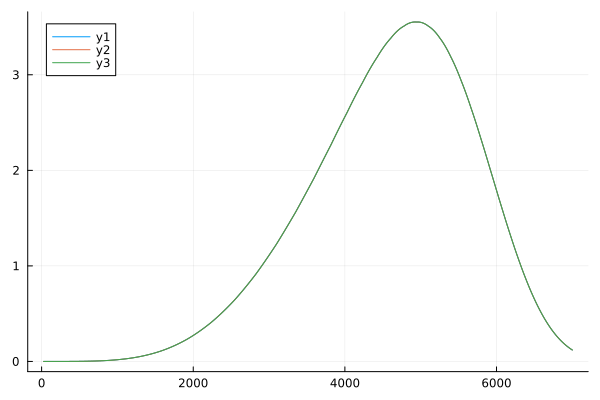

In [64]:
plot(x, gal_prefact_W)
plot!(x, Wchi)
plot!(x, Wchi_itp.(x))

In [65]:
println("Pk_grid is a vector of size $(size(Pk_grid))")

Pk_grid is a vector of size (150,)


In [70]:
function Wtilde_quadgk(ℓ::Number, k::AbstractVector{<:Real}, k1::Real;
                               xmin=xmin, xmax=xmax,
                               rtol=1e-8, atol=0.0)

    Nk = length(k)
    vals = Vector{Float64}(undef, Nk)
    errs = Vector{Float64}(undef, Nk)
    Threads.@threads for i in eachindex(k)
        ki = k[i]

        fx(x) = Wchi_itp(x) *
                SpecialFunctions.sphericalbesselj(ℓ, ki * x) *
                SpecialFunctions.sphericalbesselj(ℓ, k1 * x)

        val, err = quadgk(fx, xmin, xmax; rtol=rtol, atol=atol)

        vals[i] = k1 * val
        errs[i] = k1 * err
        #println("Wtilde_quadgk: ℓ=$ℓ, k1=$k1, ki=$ki, val=$(vals[i]), err=$(errs[i])")
    end

    return vals, errs
end

function S_l_bruteforce_quadgk(ℓ::Number, k1::Real, k2::Real, k::AbstractVector,
                               kmin_int, kmax_int,
                               xmin, xmax;
                               rtol_k = 1e-6, rtol_x = 1e-8,
                               atol_k = 0.0, atol_x = 0.0,
                               Nlg = 2/π)
    W1, _ = Wtilde_quadgk(ℓ, k, k1; xmin=xmin, xmax=xmax, rtol=rtol_x, atol=atol_x)
    #W2, _ = Wtilde_quadgk(ℓ, k, k2; xmin=xmin, xmax=xmax, rtol=rtol_x, atol=atol_x)
    println("W1 computed \n" )
    # ∫ dk k^2 P(k) W1(k) W1(k)
    integrand = k.^2 .* Pk_grid .* W1 .* W1
    val = Nlg * trapz(k, integrand)
    
    return val, 0.0
end

function compute_S(ℓ::Number, k1s::AbstractVector, k2s::AbstractVector, 
                   k::AbstractVector,
                   kmin_int, kmax_int,
                   xmin, xmax;
                   rtol_k = 1e-6, rtol_x = 1e-8,
                   atol_k = 0.0, atol_x = 0.0,
                   Nlg = 2/π)
    Nk1 = length(k1s)
    Nk2 = length(k2s)
    S = Matrix{Float64}(undef, Nk1, Nk2)
    
    Threads.@threads for i1 in eachindex(k1s)
        k1 = k1s[i1]
        row, _ = S_l_bruteforce_quadgk(ℓ, k1, k1, k, kmin_int, kmax_int,
            xmin, xmax;
            rtol_k=rtol_k, rtol_x=rtol_x,
            atol_k=atol_k, atol_x=atol_x,
            Nlg=Nlg)
        S[i1, :] .= row
    end
    
    return S
end

compute_S (generic function with 1 method)

In [125]:
# ─────────────────────────────────────────────────────────────────────────────
# Single-point benchmark: same k1 and k2
# ─────────────────────────────────────────────────────────────────────────────

ℓ_test = ℓ[20]
k_test = [0.01574015850603505]
k1_test = k_test
k2_test = k_test
println("k1_test = $k1_test h/Mpc, \nk2_test = $k2_test h/Mpc, \nℓ_test = $ℓ_test")
println("the grid in k is from $(krevgrid[1]) to $(krevgrid[end]) h/Mpc, denser at the ends and sparser in the middle - it is a Chebyshev grid")

k1_test = [0.01574015850603505] h/Mpc, 
k2_test = [0.01574015850603505] h/Mpc, 
ℓ_test = 40.0
the grid in k is from 0.00035714285714227856 to 15.384615384615385 h/Mpc, denser at the ends and sparser in the middle - it is a Chebyshev grid


In [126]:
@time Sval = compute_S(
    ℓ_test, k1_test, k2_test, krevgrid, kmin, kmax, xmin, xmax;
    rtol_k = 1e-6, rtol_x = 1e-8, atol_k = 0.0, atol_x = 0.0, Nlg = 2/π)
    println("Sval = $Sval")

W1 computed 

832.127900 seconds (14.04 G allocations: 216.916 GiB, 4.99% gc time)
Sval = [2.9433389067829524e-7;;]


In [127]:
println("Sval is a vector of FLoat64 of length ", length(Sval))
println(Sval)
println(size(Sval))
println("Sval[1] = ", Sval[1])

Sval is a vector of FLoat64 of length 1
[2.9433389067829524e-7;;]
(1, 1)
Sval[1] = 2.9433389067829524e-7


In [ ]:
#Sval[l[1]] = 1.8471673998784959e-7
#Sval[l[2]] = 1.8607501657430804e-7
#Sval[l[3]] = 1.8821804766352438e-7
#Sval[l[4]] = 1.9114851856646272e-7
#Sval[l[5]] = 1.9114851856646272e-7
#Sval[l[6]] = 1.9932621892732901e-7
#Sval[l[7]] = 2.0455876222181502e-7
#Sval[l[8]] = 2.1047403432535187e-7
#Sval[l[9]] = 2.1702203747307555e-7
#Sval[l[10]] = 2.2408287869628156e-7
#Sval[l[11]] = 2.3144868100793932e-7
#Sval[l[12]] = 2.391947376829505e-7
#Sval[l[13]] = 2.470848732315716e-7
#Sval[l[14]] = 2.549901613772657e-7
#Sval[l[15]] = 2.627846909035288e-7
#Sval[l[16]] = 2.704709816876197e-7
#Sval[l[17]] = 2.7752545760409443e-7
#Sval[l[18]] = 2.8396095664282403e-7
#Sval[l[19]] = 2.8954858770478806e-7
#Sval[l[20]] = 2.9433389067829524e-7
#Sval[l[100]] = 3.529266756774987e-80